<a href="https://colab.research.google.com/github/Anantask/Student-Placement-Analysis/blob/main/Student_Placement_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## **Import and load Dataset**

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
url='https://raw.githubusercontent.com/Anantask/Student-Placement-Analysis/refs/heads/main/student_placement_btech.csv'

In [5]:
df=pd.read_csv(url)
df

,student_id,gender,branch,tenth_percentage,twelfth_percentage,cgpa,backlogs,internship_done,placed,salary_lpa,specialisation,higher_education
0,STU1000,Female,CSE,76.6,80.5,7.85,0,1,Yes,13.76,Cybersecurity,No
1,STU1001,Male,Data Science,75.7,71.7,8.77,0,0,Yes,15.24,NLP Engineer,Yes
2,STU1002,Male,ECE,85.7,69.3,8.82,0,1,Yes,11.69,Embedded Systems,Yes
3,STU1003,Male,ECE,73.4,69.3,7.89,0,0,Yes,9.16,Embedded Systems,Yes
4,STU1004,Male,CSE,58.9,56.8,7.62,0,0,Yes,14.80,UI/UX Design,No
...,...,...,...,...,...,...,...,...,...,...,...,...
395,STU1395,Male,AIML,68.2,71.8,8.25,0,1,Yes,18.01,Deep Learning Engineer,No
396,STU1396,Male,CSE,68.3,75.1,7.90,0,0,Yes,12.18,Product Management,No
397,STU1397,Male,AIDS,72.0,77.2,6.20,2,1,No,NaN,NaN,Yes
398,STU1398,Male,CSE,82.4,73.8,5.97,2,1,Yes,11.14,Software Development,Yes


### **Data Cleaning and EDA**

In [6]:
df.head()

,student_id,gender,branch,tenth_percentage,twelfth_percentage,cgpa,backlogs,internship_done,placed,salary_lpa,specialisation,higher_education
0,STU1000,Female,CSE,76.6,80.5,7.85,0,1,Yes,13.76,Cybersecurity,No
1,STU1001,Male,Data Science,75.7,71.7,8.77,0,0,Yes,15.24,NLP Engineer,Yes
2,STU1002,Male,ECE,85.7,69.3,8.82,0,1,Yes,11.69,Embedded Systems,Yes
3,STU1003,Male,ECE,73.4,69.3,7.89,0,0,Yes,9.16,Embedded Systems,Yes
4,STU1004,Male,CSE,58.9,56.8,7.62,0,0,Yes,14.80,UI/UX Design,No


In [7]:
df.tail()

,student_id,gender,branch,tenth_percentage,twelfth_percentage,cgpa,backlogs,internship_done,placed,salary_lpa,specialisation,higher_education
395,STU1395,Male,AIML,68.2,71.8,8.25,0,1,Yes,18.01,Deep Learning Engineer,No
396,STU1396,Male,CSE,68.3,75.1,7.90,0,0,Yes,12.18,Product Management,No
397,STU1397,Male,AIDS,72.0,77.2,6.20,2,1,No,NaN,NaN,Yes
398,STU1398,Male,CSE,82.4,73.8,5.97,2,1,Yes,11.14,Software Development,Yes
399,STU1399,Male,AIDS,80.2,87.6,7.90,0,0,Yes,17.42,Data Engineering,No


In [8]:
df.shape

(400, 12)

In [9]:
df.describe()

,tenth_percentage,twelfth_percentage,cgpa,backlogs,internship_done,salary_lpa
count,400.000000,400.000000,400.000000,400.000000,400.000000,326.000000
mean,77.643500,74.766000,7.463150,0.337500,0.335000,13.861902
std,9.844959,10.141643,0.835206,0.666862,0.472582,3.373789
min,50.000000,50.000000,5.000000,0.000000,0.000000,4.000000
25%,70.500000,68.275000,6.890000,0.000000,0.000000,11.675000
50%,77.650000,74.750000,7.485000,0.000000,0.000000,14.340000
75%,84.725000,81.350000,7.950000,0.000000,1.000000,16.382500
max,100.000000,100.000000,9.720000,2.000000,1.000000,21.610000


In [10]:
df.dtypes

,0
student_id,object
gender,object
branch,object
tenth_percentage,float64
twelfth_percentage,float64
cgpa,float64
backlogs,int64
internship_done,int64
placed,object
salary_lpa,float64


In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   student_id          400 non-null    object 
 1   gender              400 non-null    object 
 2   branch              400 non-null    object 
 3   tenth_percentage    400 non-null    float64
 4   twelfth_percentage  400 non-null    float64
 5   cgpa                400 non-null    float64
 6   backlogs            400 non-null    int64  
 7   internship_done     400 non-null    int64  
 8   placed              400 non-null    object 
 9   salary_lpa          326 non-null    float64
 10  specialisation      326 non-null    object 
 11  higher_education    400 non-null    object 
dtypes: float64(4), int64(2), object(6)
memory usage: 37.6+ KB


In [12]:
df.isnull().sum()

,0
student_id,0
gender,0
branch,0
tenth_percentage,0
twelfth_percentage,0
cgpa,0
backlogs,0
internship_done,0
placed,0
salary_lpa,74


## **Feature Engineering**

In [13]:
df['academic_score'] = (df['tenth_percentage'] + df['twelfth_percentage'] + df['cgpa']*10) / 3
df['is_high_achiever'] = df['cgpa'].apply(lambda x: 'Yes' if x >= 8.5 else 'No')
df.head(3)

,student_id,gender,branch,tenth_percentage,twelfth_percentage,cgpa,backlogs,internship_done,placed,salary_lpa,specialisation,higher_education,academic_score,is_high_achiever
0,STU1000,Female,CSE,76.6,80.5,7.85,0,1,Yes,13.76,Cybersecurity,No,78.533333,No
1,STU1001,Male,Data Science,75.7,71.7,8.77,0,0,Yes,15.24,NLP Engineer,Yes,78.366667,Yes
2,STU1002,Male,ECE,85.7,69.3,8.82,0,1,Yes,11.69,Embedded Systems,Yes,81.066667,Yes


## **Visualization**


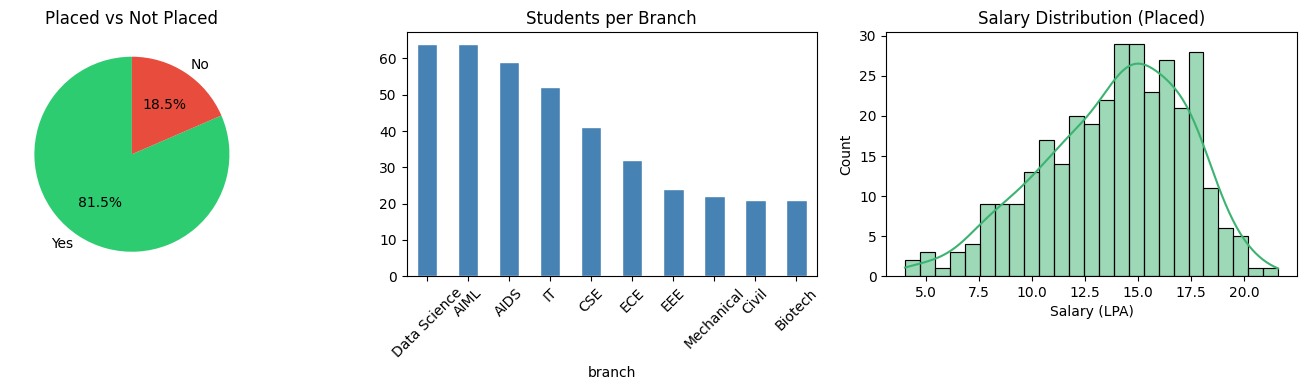

In [14]:
# Placement rate + salary distribution
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

df['placed'].value_counts().plot(kind='pie', ax=axes[0],
    autopct='%1.1f%%', colors=['#2ecc71','#e74c3c'], startangle=90)
axes[0].set_title('Placed vs Not Placed')
axes[0].set_ylabel('')

df['branch'].value_counts().plot(kind='bar', ax=axes[1],
    color='steelblue', edgecolor='white')
axes[1].set_title('Students per Branch')
axes[1].tick_params(axis='x', rotation=45)

df_placed = df[df['placed'] == 'Yes']
sns.histplot(df_placed['salary_lpa'], bins=25, kde=True,
             color='mediumseagreen', ax=axes[2])
axes[2].set_title('Salary Distribution (Placed)')
axes[2].set_xlabel('Salary (LPA)')

plt.tight_layout()
plt.show()

/tmp/ipykernel_911/2570121936.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='placed', y='cgpa', data=df,


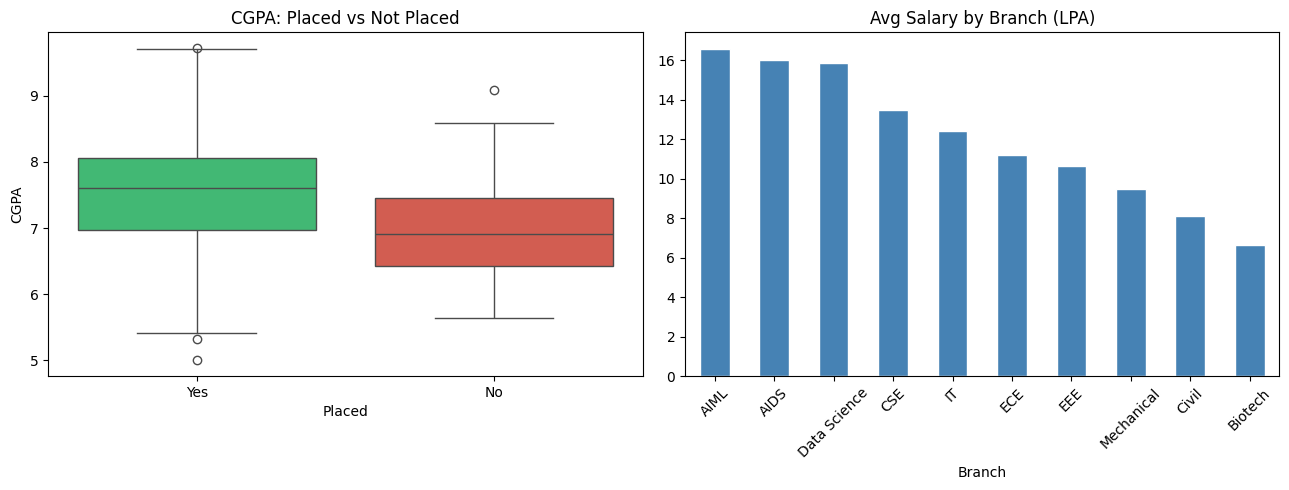

In [15]:
# CGPA vs placement, branch vs salary
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

sns.boxplot(x='placed', y='cgpa', data=df,
            palette={'Yes':'#2ecc71','No':'#e74c3c'}, ax=axes[0])
axes[0].set_title('CGPA: Placed vs Not Placed')
axes[0].set_xlabel('Placed')
axes[0].set_ylabel('CGPA')

branch_sal = df_placed.groupby('branch')['salary_lpa'].mean().sort_values(ascending=False)
branch_sal.plot(kind='bar', color='steelblue', edgecolor='white', ax=axes[1])
axes[1].set_title('Avg Salary by Branch (LPA)')
axes[1].set_xlabel('Branch')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

/tmp/ipykernel_911/3513261342.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='internship_done', y='placement_rate',


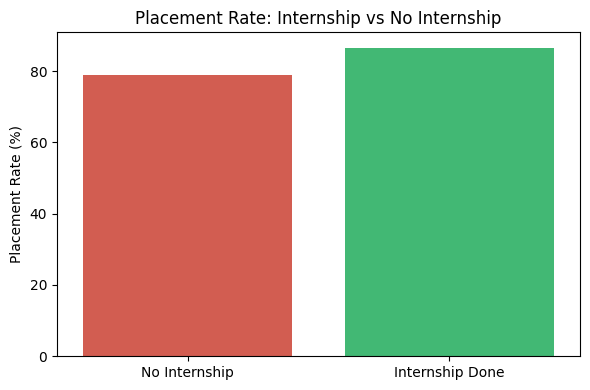

In [16]:
# Does internship help placement?
internship_place = df.groupby('internship_done')['placed'].apply(
    lambda x: (x == 'Yes').mean() * 100).reset_index()
internship_place.columns = ['internship_done','placement_rate']
internship_place['internship_done'] = internship_place['internship_done'].map({0:'No Internship', 1:'Internship Done'})

plt.figure(figsize=(6, 4))
sns.barplot(x='internship_done', y='placement_rate',
            data=internship_place, palette=['#e74c3c','#2ecc71'])
plt.title('Placement Rate: Internship vs No Internship')
plt.ylabel('Placement Rate (%)')
plt.xlabel('')
plt.tight_layout()
plt.show()

##  Key Insights — Student Placement EDA

1. **65% students got placed** — AIML, Data Science and AIDS branches dominate the dataset.
2. **CGPA matters** — placed students consistently have higher CGPA than unplaced ones.
3. **Internship significantly boosts placement rate** — one of the strongest factors.
4. **AIML and Data Science pay the most** — averaging 14–16 LPA vs 6–7 LPA for Civil/Mechanical.
5. **Salary is right skewed** — most land between 8–14 LPA, very few cross 18+ LPA.